In [1]:
import os
import json
import cv2
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tqdm import tqdm
import matplotlib.pyplot as plt
import re
import shutil
import random
from pathlib import Path
from tqdm.notebook import tqdm

In [2]:
# Avoid OOM errors by setting GPU Memory Consumption Growth
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus: 
    tf.config.experimental.set_memory_growth(gpu, True)

In [28]:
# --- CONFIGURACIÓN ---

# 1. Directorio donde están tus placas recortadas Y sus JSONs
# (Ej. 166x88-ABC-123.jpg y 166x88-ABC-123.json)
#SOURCE_DATA_DIR = ""

# 2. Directorio donde guardaremos el NUEVO dataset de caracteres individuales
# (El script lo creará)
CLASSIFICATION_DATASET_DIR = "datasets/extracted_characters_dirt/"

# 3. Tamaño estándar al que redimensionaremos CADA CARACTER individual
# 48x48 es un buen tamaño para que la CNN aprenda
CHAR_IMG_SIZE = (48, 48)

BATCH_SIZE = 256

In [29]:
# --- ¡CAMBIO CLAVE! ---
# Apuntar al NUEVO dataset que acabamos de balancear
#CLASSIFICATION_DATASET_DIR = "Dataset/balanced_characters_max/"
# ---------------------

# (El resto de tu código de la CELDA 2 no necesita cambios)
# Dividir el dataset: 80% para entrenamiento, 20% para validación
train_dataset = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=CHAR_IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale' # Entrenar en escala de grises
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    CLASSIFICATION_DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=CHAR_IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

# Guardar los nombres de las clases (ej. ['0', '1', 'A', 'B'...])
class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"Dataset BALANCEADO cargado. Encontradas {num_classes} clases: {class_names}")

# Optimizar los pipelines de datos
train_dataset = train_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

print("Pipelines de datos listos para el entrenamiento.")

Found 37276 files belonging to 37 classes.
Using 29821 files for training.
Found 37276 files belonging to 37 classes.
Using 7455 files for validation.
Dataset BALANCEADO cargado. Encontradas 37 clases: ['-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Pipelines de datos listos para el entrenamiento.


In [ ]:
def build_char_classifier(input_shape, num_classes):
    input_img = layers.Input(shape=input_shape, name="image")
    
    x = layers.Rescaling(1./255)(input_img)

    # 1. Cuerpo (sin cambios)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)    
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.SpatialDropout2D(0.25)(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.SpatialDropout2D(0.25)(x)
    
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.SpatialDropout2D(0.25)(x)

    # 2. Cabeza (MODIFICADA)
    #x = layers.GlobalAveragePooling2D()(x)
    x = layers.Flatten()(x)  # Vector de 1152 características (6*6*32)
    x = layers.Dropout(0.5)(x) # Dropout principal después de extraer características
    

    x = layers.Dense(256, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(32, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.3)(x)
    
    # Capa de salida final
    output = layers.Dense(num_classes, activation="softmax", name="output")(x)
    
    model = Model(inputs=input_img, outputs=output, name="char_classifier")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# --- Construir el modelo mejorado ---
classifier_model = build_char_classifier(
    input_shape=(48, 48, 1), 
    num_classes=num_classes
)
classifier_model.summary()

Model: "char_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, 48, 48, 1)]       0         
                                                                 
 rescaling_6 (Rescaling)     (None, 48, 48, 1)         0         
                                                                 
 conv2d_36 (Conv2D)          (None, 48, 48, 32)        320       
                                                                 
 batch_normalization_42 (Bat  (None, 48, 48, 32)       128       
 chNormalization)                                                
                                                                 
 conv2d_37 (Conv2D)          (None, 48, 48, 32)        9248      
                                                                 
 batch_normalization_43 (Bat  (None, 48, 48, 32)       128       
 chNormalization)                                  

In [ ]:
import os
from tensorflow import keras

# --- 1. CONFIGURACIÓN ---
# ⚠️ ¡Ajusta estas rutas! ⚠️

# Define el nombre con el que se GUARDARÁ el nuevo modelo entrenado
SAVE_MODEL_PATH = "checkpoints/best_CNN_char_classifier_v8.keras"

# Define el modelo que quieres CARGAR para continuar entrenando.
# Si pones 'None', se creará un modelo nuevo desde cero.
LOAD_MODEL_PATH = "checkpoints/best_CNN_char_classifier_v7.keras" # Ejemplo: Cargar v6 para crear v7

# Parámetros de entrenamiento
EPOCHS = 50
BATCH_SIZE = 256
# --------------------------


# --- 2. LÓGICA DE DECISIÓN ---
# (Asumimos que 'build_char_classifier' y 'num_classes' ya existen)

# Comprobar si se especificó un modelo para cargar Y si el archivo existe
if LOAD_MODEL_PATH and os.path.exists(LOAD_MODEL_PATH):
    # --- Cargar y continuar entrenando ---
    print(f"✅ Modelo encontrado en '{LOAD_MODEL_PATH}'. Cargando para continuar entrenamiento...")
    
    classifier_model = keras.models.load_model(LOAD_MODEL_PATH)
    
    # Bajar la tasa de aprendizaje para un ajuste fino
    keras.backend.set_value(classifier_model.optimizer.learning_rate, 1e-3)
    print(f"Tasa de aprendizaje ajustada para fine-tuning a: {keras.backend.get_value(classifier_model.optimizer.learning_rate)}")

else:
    # --- Construir desde cero ---
    print(f"⚠️ No se especificó un modelo para cargar o no se encontró. Construyendo uno nuevo que se guardará como '{SAVE_MODEL_PATH}'...")
    
    classifier_model = build_char_classifier(
        input_shape=(48, 48, 1), 
        num_classes=num_classes
    )

print("\n--- Resumen del Modelo ---")
classifier_model.summary()

# --- 3. ENTRENAMIENTO ---
# El callback ahora usa SAVE_MODEL_PATH para no sobrescribir el original

# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=30, restore_best_weights=True
)
checkpoint = keras.callbacks.ModelCheckpoint(
    SAVE_MODEL_PATH,  # <-- ¡CAMBIO CLAVE! Guarda en la nueva ruta
    monitor="val_loss", 
    save_best_only=True, 
    mode="min"
)

# Iniciar o continuar el entrenamiento
history = classifier_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    # batch_size=BATCH_SIZE, # Ya no es necesario si usas un tf.data.Dataset bateado
    callbacks=[early_stopping, checkpoint]
)

✅ Modelo encontrado en 'best_CNN_char_classifier_v7.keras'. Cargando para continuar entrenamiento...
Tasa de aprendizaje ajustada para fine-tuning a: 0.0010000000474974513

--- Resumen del Modelo ---
Model: "char_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, 48, 48, 1)]       0         
                                                                 
 rescaling_3 (Rescaling)     (None, 48, 48, 1)         0         
                                                                 
 conv2d_18 (Conv2D)          (None, 48, 48, 32)        320       
                                                                 
 batch_normalization_18 (Bat  (None, 48, 48, 32)       128       
 chNormalization)                                                
                                                                 
 conv2d_19 (Conv2D)          (None, 48, 48, 32)  

1/1 [==============================] - 0s 109ms/step
Total de muestras de validación: 7455
Predicciones incorrectas: 37 (0.50%)

Classification Report:
              precision    recall  f1-score   support

           -       0.98      0.99      0.98       613
           0       0.77      0.92      0.84       327
           1       0.97      0.95      0.96       320
           2       0.99      0.99      0.99       333
           3       0.96      0.97      0.96       379
           4       0.97      0.99      0.98       348
           5       0.96      0.98      0.97       340
           6       0.98      0.99      0.98       371
           7       0.98      0.97      0.98       357
           8       0.95      0.97      0.96       340
           9       0.98      0.98      0.98       363
           A       0.98      0.95      0.96       125
           B       0.98      0.95      0.96       131
           C       0.99      0.96      0.97       155
           D       0.96      0.99    

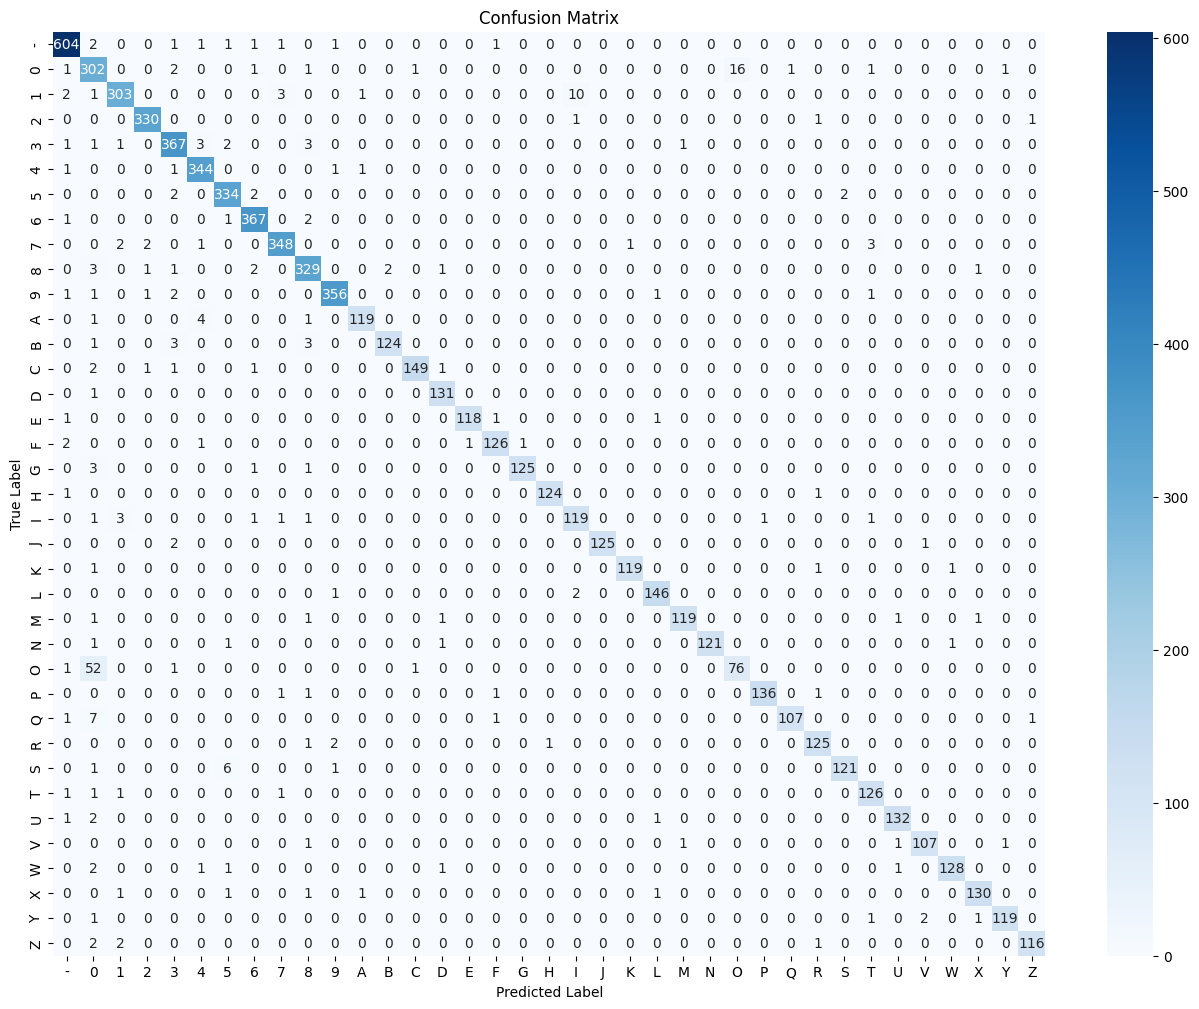

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

loaded_model = keras.models.load_model("checkpoints/best_CNN_char_classifier_v8.keras")

# Volver a compilar con los mismos parámetros
#loaded_model.compile(
#    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
#    loss="sparse_categorical_crossentropy",
#    metrics=["accuracy"]
#)

# Preparar listas para almacenar las etiquetas verdaderas y las predicciones
true_labels = []
predicted_labels = []

# Iterar sobre el conjunto de datos de validación para obtener las etiquetas verdaderas y las predicciones
for images, labels in validation_dataset:
    predictions = loaded_model.predict(images)
    predicted_batch_labels = np.argmax(predictions, axis=1)  # Obtener la clase predicha con la mayor probabilidad
    
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_batch_labels)

# Calcular la matriz de confusión
confusion_mtx = confusion_matrix(true_labels, predicted_labels)

# Calcular el número total de muestras de validación
total_validation_samples = len(true_labels)

# Calcular el número de predicciones incorrectas
incorrect_predictions = np.sum(np.diag(confusion_mtx) != np.sum(confusion_mtx, axis=1))

# Calcular el porcentaje de predicciones incorrectas
incorrect_percentage = (incorrect_predictions / total_validation_samples) * 100

print(f"Total de muestras de validación: {total_validation_samples}")
print(f"Predicciones incorrectas: {incorrect_predictions} ({incorrect_percentage:.2f}%)")

# Imprimir reporte de clasificación
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

# Visualizar la matriz de confusión
plt.figure(figsize=(16, 12))
sns.heatmap(confusion_mtx, 
            annot=True, 
            fmt='g', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [34]:
validation_dataset_other = tf.keras.utils.image_dataset_from_directory(
    "datasets/extracted_characters/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=CHAR_IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode='grayscale'
)

validation_dataset_other = validation_dataset_other.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 73910 files belonging to 37 classes.
Using 14782 files for validation.


6/6 [==============================] - 0s 4ms/step
Total de muestras de validación: 14782
Predicciones incorrectas: 17 (0.12%)

Classification Report:
              precision    recall  f1-score   support

           -       1.00      1.00      1.00      1193
           0       0.87      0.99      0.93       661
           1       0.99      0.99      0.99       705
           2       1.00      1.00      1.00       694
           3       1.00      1.00      1.00       689
           4       1.00      1.00      1.00       678
           5       0.99      1.00      1.00       693
           6       1.00      1.00      1.00       680
           7       1.00      1.00      1.00       636
           8       1.00      1.00      1.00       692
           9       1.00      1.00      1.00       671
           A       1.00      1.00      1.00       267
           B       1.00      1.00      1.00       253
           C       1.00      1.00      1.00       257
           D       0.98      1.00     

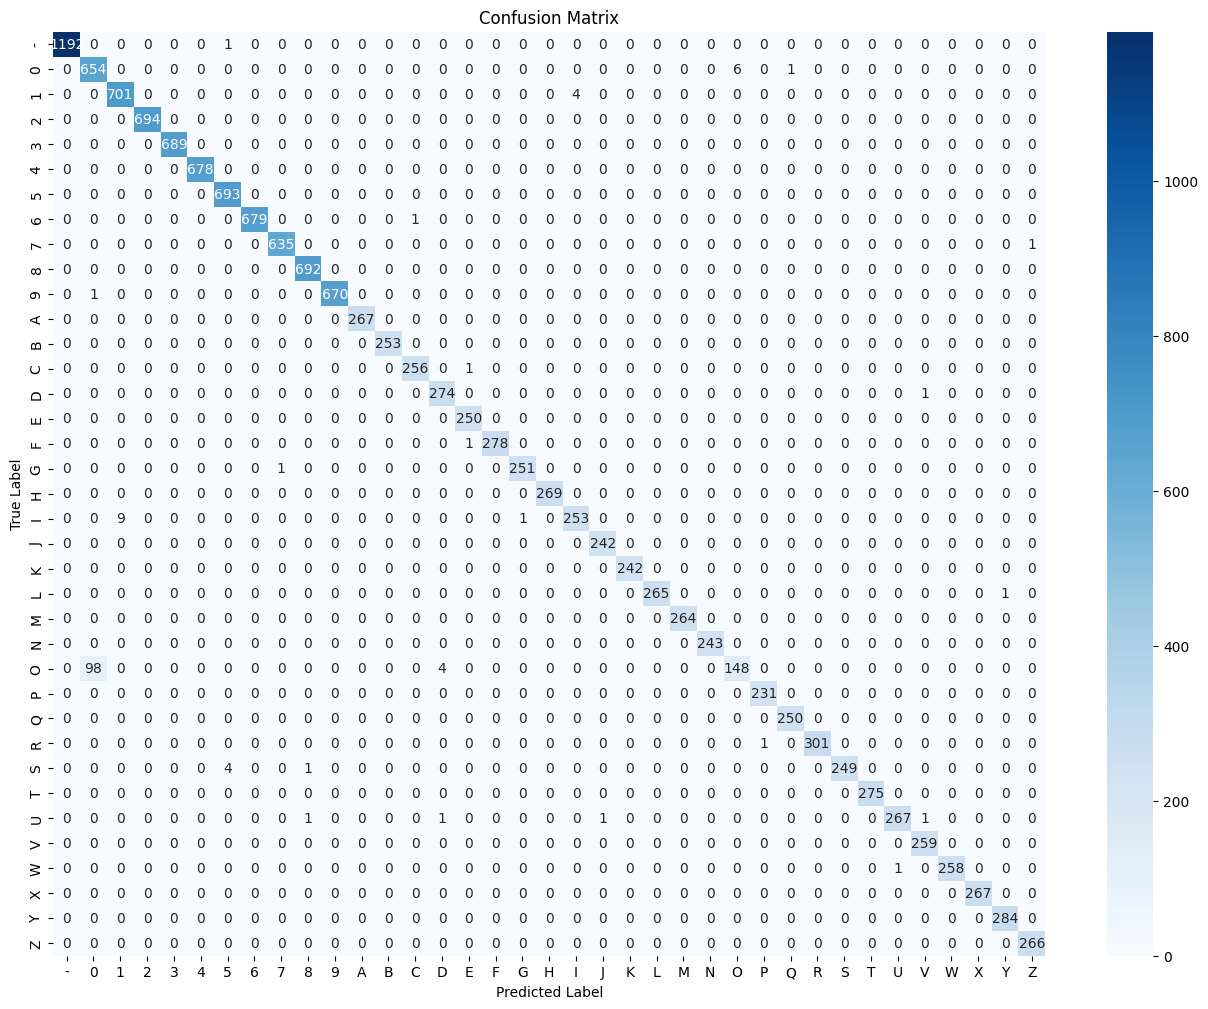

In [38]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

loaded_model = keras.models.load_model("best_CNN_char_classifier_v7.keras")

# Preparar listas para almacenar las etiquetas verdaderas y las predicciones
true_labels = []
predicted_labels = []

# Iterar sobre el conjunto de datos de validación para obtener las etiquetas verdaderas y las predicciones
for images, labels in validation_dataset_other:
    predictions = loaded_model.predict(images)
    predicted_batch_labels = np.argmax(predictions, axis=1)  # Obtener la clase predicha con la mayor probabilidad
    
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_batch_labels)

# Calcular la matriz de confusión
confusion_mtx = confusion_matrix(true_labels, predicted_labels)

# Calcular el número total de muestras de validación
total_validation_samples = len(true_labels)

# Calcular el número de predicciones incorrectas
incorrect_predictions = np.sum(np.diag(confusion_mtx) != np.sum(confusion_mtx, axis=1))

# Calcular el porcentaje de predicciones incorrectas
incorrect_percentage = (incorrect_predictions / total_validation_samples) * 100

print(f"Total de muestras de validación: {total_validation_samples}")
print(f"Predicciones incorrectas: {incorrect_predictions} ({incorrect_percentage:.2f}%)")

# Imprimir reporte de clasificación
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels, target_names=class_names))

# Visualizar la matriz de confusión
plt.figure(figsize=(16, 12))
sns.heatmap(confusion_mtx, 
            annot=True, 
            fmt='g', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Obteniendo predicciones del dataset de validación...
Unificando clases 'I'/'1' y 'O'/'0'...
✅ Clases unificadas.

📊 Reporte de Clasificación (con I=1, O=0):
              precision    recall  f1-score   support

           -       1.00      1.00      1.00      1193
           0       1.00      1.00      1.00       911
           1       1.00      1.00      1.00       968
           2       1.00      1.00      1.00       694
           3       1.00      1.00      1.00       689
           4       1.00      1.00      1.00       678
           5       0.98      1.00      0.99       693
           6       1.00      1.00      1.00       680
           7       1.00      1.00      1.00       636
           8       1.00      1.00      1.00       692
           9       1.00      1.00      1.00       671
           A       1.00      1.00      1.00       267
           B       0.99      1.00      1.00       253
           C       1.00      1.00      1.00       257
           D       0.99      0.9

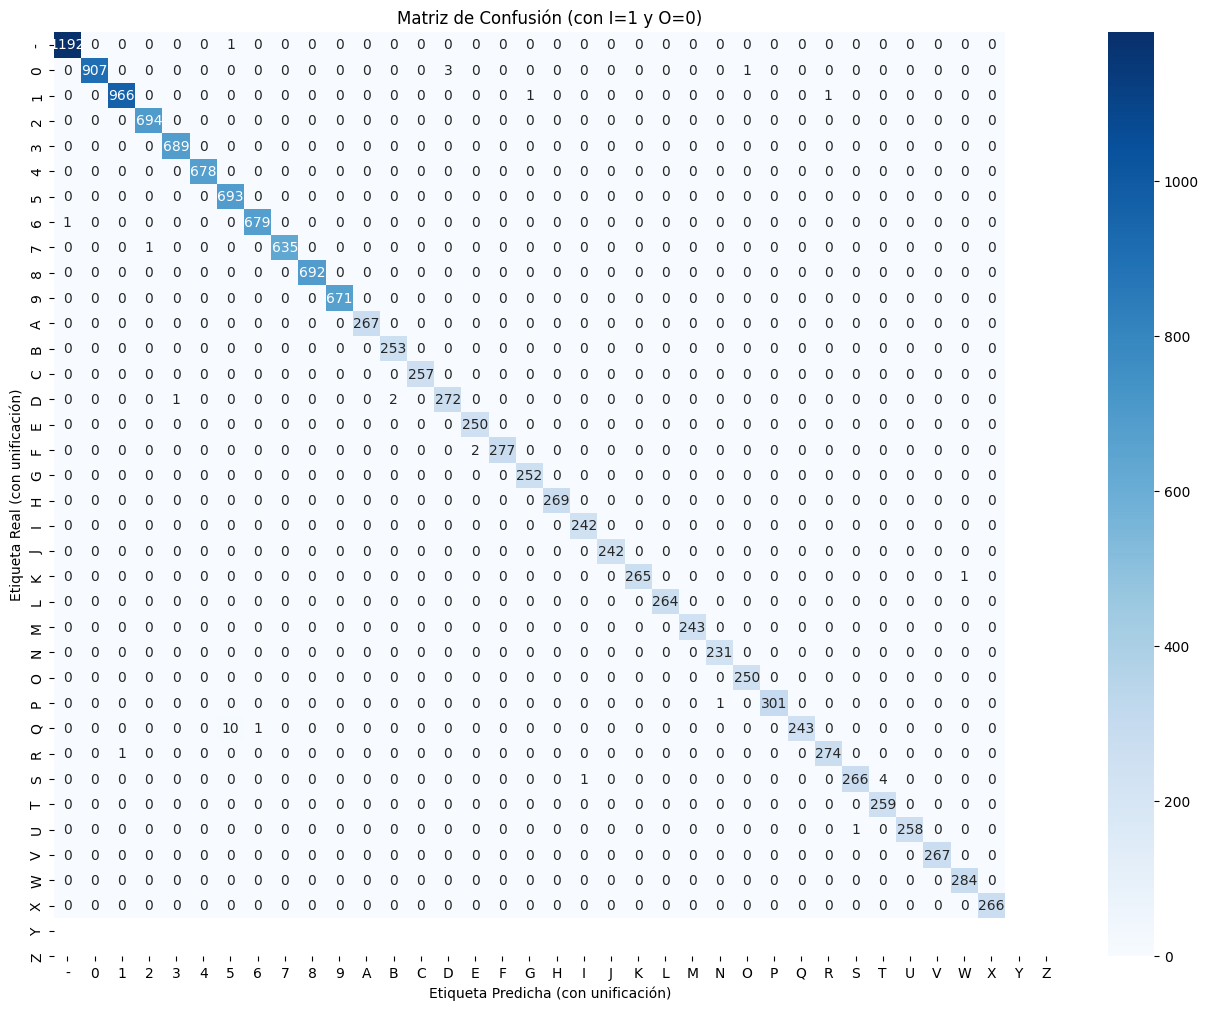

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Obtener Predicciones (Sin cambios) ---
# (Asumimos que 'validation_dataset', 'classifier_model', y 'class_names' ya existen)

print("Obteniendo predicciones del dataset de validación...")
true_labels = []
predicted_labels = []

# Iterar sobre el conjunto de datos para obtener las etiquetas y predicciones originales
for images, labels in validation_dataset:
    predictions = classifier_model.predict(images, verbose=0)
    predicted_batch_labels = np.argmax(predictions, axis=1)
    
    true_labels.extend(labels.numpy())
    predicted_labels.extend(predicted_batch_labels)

# --- 2. NUEVO: Mapeo de Clases (Unificar I/1 y O/0) ---

print("Unificando clases 'I'/'1' y 'O'/'0'...")

# Encontrar los IDs numéricos de las clases que queremos unificar
# Usamos un try-except por si alguna clase no estuviera en el dataset
try:
    idx_I = class_names.index('I')
    idx_1 = class_names.index('1')
    idx_O = class_names.index('O')
    idx_0 = class_names.index('0')

    # Crear un diccionario de mapeo: todas las 'I' se convertirán en '1', y las 'O' en '0'
    class_map = {
        idx_I: idx_1,
        idx_O: idx_0
    }

    # Aplicar el mapeo a ambas listas de etiquetas
    # .get(label, label) significa: "busca 'label' en el mapa. Si lo encuentras, usa su valor. Si no, usa el 'label' original."
    true_labels_merged = [class_map.get(label, label) for label in true_labels]
    predicted_labels_merged = [class_map.get(label, label) for label in predicted_labels]
    
    print("✅ Clases unificadas.")

except ValueError as e:
    print(f"⚠️ Advertencia: No se encontraron todas las clases a unificar ('I', '1', 'O', '0') en 'class_names'. Se usarán las etiquetas originales. Error: {e}")
    # Si falta alguna clase, simplemente usamos las listas originales sin modificar
    true_labels_merged = true_labels
    predicted_labels_merged = predicted_labels


# --- 3. Calcular y Mostrar Resultados (Usando las etiquetas UNIFICADAS) ---

# Calcular la matriz de confusión con las etiquetas modificadas
confusion_mtx = confusion_matrix(true_labels_merged, predicted_labels_merged)

# Filter class_names to include only the classes present after merging
present_classes = sorted(list(set(true_labels_merged + predicted_labels_merged)))
present_class_names = [class_names[i] for i in present_classes]

# Imprimir reporte de clasificación
print("\n📊 Reporte de Clasificación (con I=1, O=0):")
# Use the filtered class names in the classification report
print(classification_report(true_labels_merged, predicted_labels_merged, target_names=present_class_names, zero_division=0))

# Visualizar la matriz de confusión
plt.figure(figsize=(16, 12))
sns.heatmap(confusion_mtx, 
            annot=True, 
            fmt='g', 
            xticklabels=class_names, 
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel('Etiqueta Predicha (con unificación)')
plt.ylabel('Etiqueta Real (con unificación)')
plt.title('Matriz de Confusión (con I=1 y O=0)')
plt.show()

In [45]:
import tensorflow as tf
import cv2
import numpy as np

# --- ¡CAMBIO CLAVE! ---
# La lista de clases debe estar disponible globalmente para la función
# Asegúrate de que este orden sea el correcto
KERAS_CLASS_NAMES = ['-', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']

def predict_character(image_path, model, class_names, img_size=(48, 48)):
    """
    Realiza la predicción de un caracter en una imagen.
    
    Args:
        image_path (str): Ruta a la imagen del caracter.
        model (tf.keras.Model): El modelo de Keras ya cargado.
        class_names (list): La lista de nombres de las clases.
        img_size (tuple): El tamaño de entrada del modelo.

    Returns:
        str: El caracter predicho.
    """
    # Cargar y preprocesar la imagen
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"No se pudo cargar la imagen en: {image_path}")

    img_resized = cv2.resize(img, img_size)
    
    # --- ¡CAMBIO CLAVE! ---
    # 1. NO normalizamos aquí. El modelo lo hace.
    # 2. Convertimos a float32, que es lo que Keras prefiere.
    img_float = img_resized.astype('float32')
    
    # Agregar canal y dimensión de lote
    img_expanded = np.expand_dims(img_float, axis=-1)
    img_batch = np.expand_dims(img_expanded, axis=0)

    # Realizar la predicción
    prediction = model.predict(img_batch, verbose=0)
    predicted_class_index = np.argmax(prediction)
    
    predicted_character = class_names[predicted_class_index]

    return predicted_character

# --- Ejemplo de uso (La forma correcta y rápida) ---
if __name__ == '__main__':
    image_path = "datasets/eval_final/a.png"  # Reemplaza con la ruta a tu imagen de prueba
    model_path = "checkpoints/CNN_char_classifier.keras"  # Reemplaza con la ruta a tu modelo

    try:
        # 🚀 1. Cargar el modelo UNA SOLA VEZ
        print(f"Cargando modelo desde: {model_path}...")
        classifier_model = tf.keras.models.load_model(model_path, compile=False)
        print("¡Modelo cargado!")

        # 🚀 2. Realizar la predicción pasando el modelo cargado
        predicted_char = predict_character(
            image_path, 
            classifier_model, 
            KERAS_CLASS_NAMES
        )
        print(f"\nEl caracter predicho es: {predicted_char}")

    except Exception as e:
        print(f"Error durante la predicción: {e}")

Cargando modelo desde: checkpoints/CNN_char_classifier.keras...
¡Modelo cargado!

El caracter predicho es: A
